In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
rc('animation', html='jshtml')

In [2]:
import math


def fibonacci_sphere(samples, amplitude, xc, yc, zc):

    points = []
    phi = np.pi * (3. - np.sqrt(5.))  # golden angle in radians

    for i in range(samples):
        y = amplitude[i]*(1 - (i / float(samples - 1)) * 2)  # y goes from 1 to -1
        radius = np.sqrt(amplitude[i]**2 - y * y)  # radius at y

        theta = phi * i  # golden angle increment

        x = np.cos(theta) * radius
        z = np.sin(theta) * radius

        points.append((x+xc, y+yc, z+zc))

    return np.transpose(points)

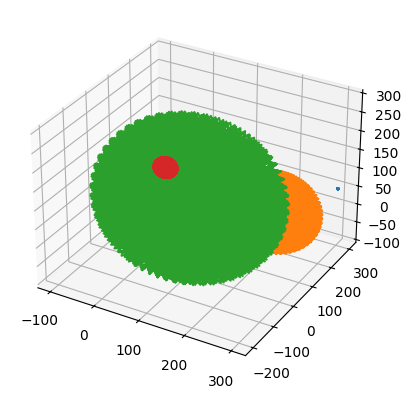

In [24]:
Nbody = 1000
xyz = np.linspace(-1,1,Nbody)

lamb1 = 1E20
A1 = 1*np.cos(2*np.pi/lamb1 * xyz) # wave function amplitude
s1 = fibonacci_sphere(Nbody,A1,300,300,50)


lamb2 = 1E100
A2 = 100*np.cos(2*np.pi/lamb2 * xyz) # wave function amplitude
s2 = fibonacci_sphere(Nbody,A2,200,200,0)


lamb3 = 1E30
A3 = 200*np.cos(2*np.pi/lamb3 * xyz) # wave function amplitude
s3 = fibonacci_sphere(Nbody,A3,100,0,100)


lamb4 = 1E40
A4 = 25*np.cos(2*np.pi/lamb4 * xyz) # wave function amplitude
s4 = fibonacci_sphere(Nbody,A4,0,100,100)

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(s1[0],s1[1],s1[2])
ax.plot3D(s2[0],s2[1],s2[2])
ax.plot3D(s3[0],s3[1],s3[2])
ax.plot3D(s4[0],s4[1],s4[2])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from numba import njit, prange

fig = plt.figure()
ax = plt.axes(projection='3d')

bodies = [s1, s2, s3, s4]
amps   = [A1, A2, A3, A4]
colors = ['r', 'b', 'g', 'm']

Ns = [b.shape[1] for b in bodies]
P = np.vstack([b.T for b in bodies])
V = np.zeros_like(P)
AMP = np.concatenate(amps)
body_id = np.concatenate([np.full(Ns[i], i) for i in range(len(bodies))])

G = 25.0
softening2 = 25.0**2
damping = 0.995
dt = 1.0
VMAX = 15.0
Nbody = 1000   # <-- per-sphere sample count, matches your original definition exactly

xlim, ylim, zlim = [-100, 250], [50, 300], [-50, 100]
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)

masks = [body_id == i for i in range(len(bodies))]
scatters = [
    ax.scatter3D(P[m, 0], P[m, 1], P[m, 2], color=colors[i], s=4)
    for i, m in enumerate(masks)
]

@njit(parallel=True, fastmath=True, cache=True)
def compute_accel(P, AMP, G, softening2, Nbody):
    N = P.shape[0]
    accel = np.zeros((N, 3))
    absAMP = np.abs(AMP)
    for i in prange(N):
        ax_ = ay_ = az_ = 0.0
        for j in range(N):
            if i == j:
                continue
            dx = P[j, 0] - P[i, 0]
            dy = P[j, 1] - P[i, 1]
            dz = P[j, 2] - P[i, 2]
            dist2 = dx*dx + dy*dy + dz*dz + softening2
            dist = np.sqrt(dist2)
            f = G * absAMP[i] * absAMP[j] / (dist2 * dist)
            ax_ += f * dx; ay_ += f * dy; az_ += f * dz
        accel[i, 0] = ax_ / Nbody
        accel[i, 1] = ay_ / Nbody
        accel[i, 2] = az_ / Nbody
    return accel

_ = compute_accel(P, AMP, G, softening2, Nbody)  # warm up JIT before animation starts

def frame(w):
    global P, V
    accel = compute_accel(P, AMP, G, softening2, Nbody)
    V[:] = np.clip((V + accel * dt) * damping, -VMAX, VMAX)
    P += V * dt
    for sc, m in zip(scatters, masks):
        sc._offsets3d = (P[m, 0], P[m, 1], P[m, 2])
    return scatters

plt.close()
anim = animation.FuncAnimation(fig, frame, frames=900, blit=False, repeat=True)
anim